# Getting Started with Beta KDE
beta-kde is a drop-in replacement for Scikit-learn's density estimators, optimized for bounded data. This notebook demonstrates its advantages over standard Gaussian KDEs and how to use it for multivariate data.

In [29]:
# Install the package if you haven't already
# !pip install beta-kde

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from beta_kde import BetaKDE

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1D Example - The Boundary Bias Problem
Standard Gaussian KDEs assume data extends to infinity. When applied to bounded data (e.g., probabilities in $[0, 1]$), they "leak" probability mass and underestimate density at the edges.

BetaKDE uses asymmetric kernels to fix this naturally.

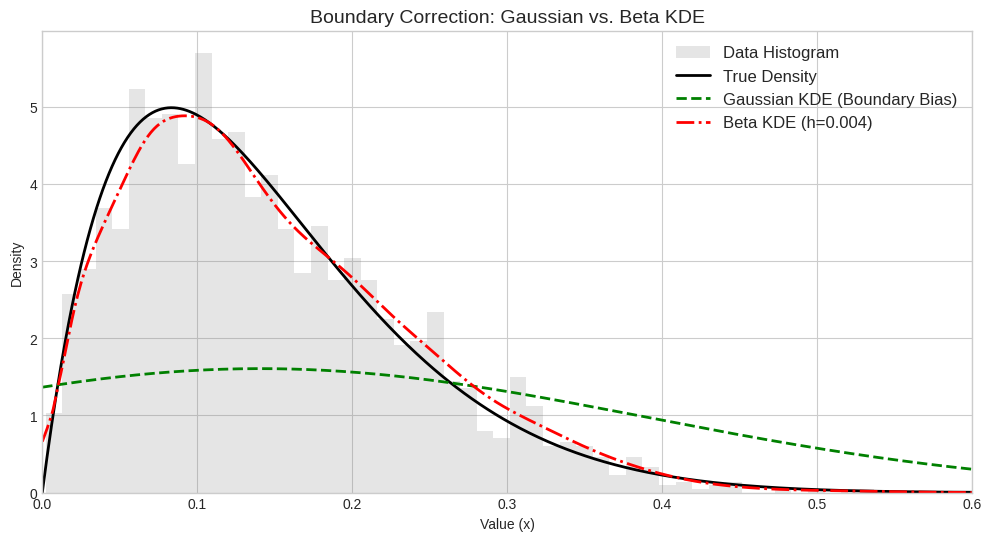

In [30]:
# 1. Generate Data: Beta(2, 12)
# This distribution is highly skewed towards 0, making it a perfect stress test.
n_samples = 2000
X = np.random.beta(2, 12, size=(n_samples, 1))

# 2. Fit Standard Gaussian KDE (Baseline)
# Using Silverman's rule for fair comparison
kde_gauss = KernelDensity(kernel='gaussian', bandwidth='silverman').fit(X)

# 3. Fit Beta KDE (Proposed)
# Uses the 'beta-reference' rule by default (fast & accurate)
kde_beta = BetaKDE(bandwidth='beta-reference').fit(X)

# 4. Evaluate
x_grid = np.linspace(0, 1, 1000).reshape(-1, 1)
pdf_true = beta.pdf(x_grid, 2, 12)
pdf_gauss = np.exp(kde_gauss.score_samples(x_grid))
pdf_beta = np.exp(kde_beta.score_samples(x_grid))

# 5. Plot
plt.figure(figsize=(12, 6))
plt.hist(X, bins=50, density=True, alpha=0.2, color='gray', label='Data Histogram')
plt.plot(x_grid, pdf_true, 'k-', lw=2, label='True Density')
plt.plot(x_grid, pdf_gauss, 'g--', lw=2, label='Gaussian KDE (Boundary Bias)')
plt.plot(x_grid, pdf_beta, 'r-.', lw=2, label=f'Beta KDE (h={kde_beta.bandwidth_:.3f})')

plt.title("Boundary Correction: Gaussian vs. Beta KDE", fontsize=14)
plt.xlabel("Value (x)")
plt.ylabel("Density")
plt.xlim(0, 0.6)  # Zoom in on the boundary
plt.legend(fontsize=12)
plt.show()

We can also generate a plot using the plot() method in BetaKDE

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Beta Kernel Density Estimation'}>)

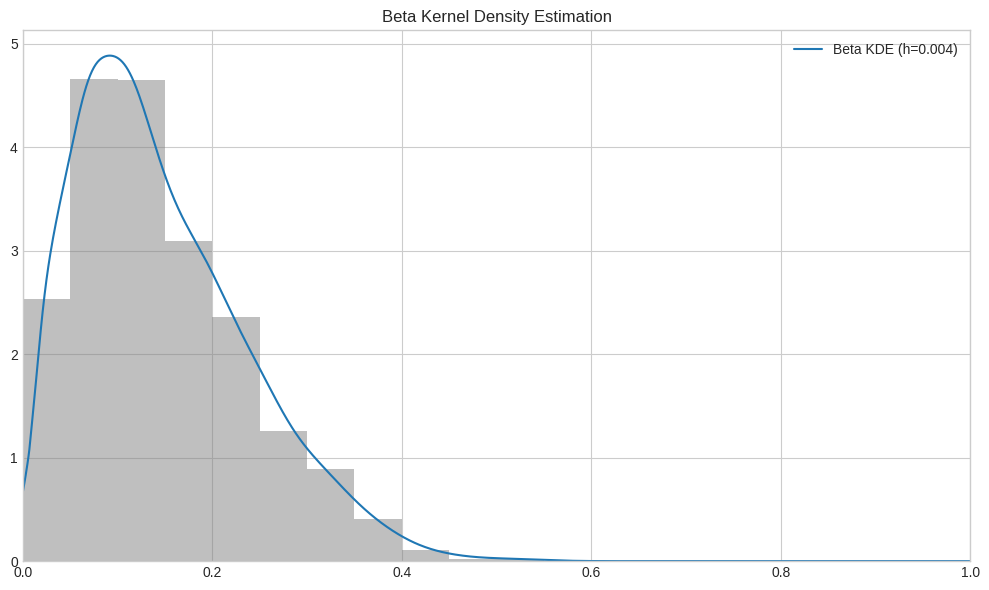

In [31]:
kde_beta.plot()

## 2D Example - Multivariate Copulas
For multidimensional data, BetaKDE fits marginal distributions independently and models their dependence structure using a Non-Parametric Beta Copula.

This allows it to capture complex, non-linear dependencies without assuming a specific parametric shape (like a Gaussian Copula).

Marginal Bandwidths: [np.float64(0.021114962692968715), np.float64(0.0059722571945365465)]
Copula Bandwidth:    0.2817


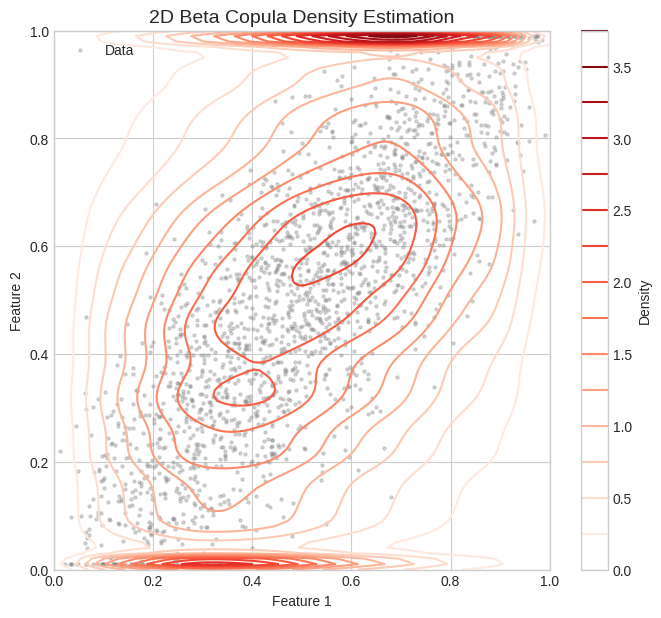

In [32]:
# 1. Generate Correlated Data (Clayton-like dependence)
# x is uniform, y is dependent on x
n = 2000
x = np.random.beta(2, 2, size=n)
y = x + np.random.normal(0, 0.15, size=n)
# Clip to strict [0, 1] bounds
data_2d = np.column_stack((np.clip(x, 0.01, 0.99), np.clip(y, 0.01, 0.99)))

# 2. Fit Beta KDE
# Automatically detects 2D input and enables Copula mode
kde_2d = BetaKDE(bandwidth='beta-reference').fit(data_2d)

print(f"Marginal Bandwidths: {kde_2d.marginal_bandwidths_}")
print(f"Copula Bandwidth:    {kde_2d.copula_bandwidth_:.4f}")

# 3. Evaluate on Grid for Contour Plot
grid_pts = np.linspace(0, 1, 100)
X_grid, Y_grid = np.meshgrid(grid_pts, grid_pts)
XY_flat = np.column_stack((X_grid.ravel(), Y_grid.ravel()))

# Score samples returns log-likelihood
Z_log = kde_2d.score_samples(XY_flat)
Z = np.exp(Z_log).reshape(100, 100)

# 4. Plot
plt.figure(figsize=(8, 7))
plt.scatter(data_2d[:, 0], data_2d[:, 1], s=5, alpha=0.3, color='gray', label='Data')
plt.contour(X_grid, Y_grid, Z, levels=15, cmap='Reds', linewidths=1.5)
plt.title("2D Beta Copula Density Estimation", fontsize=14)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Density")
plt.legend()
plt.show()

Plot the marginals

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Dimension 1'}>,
        <Axes: title={'center': 'Dimension 2'}>], dtype=object))

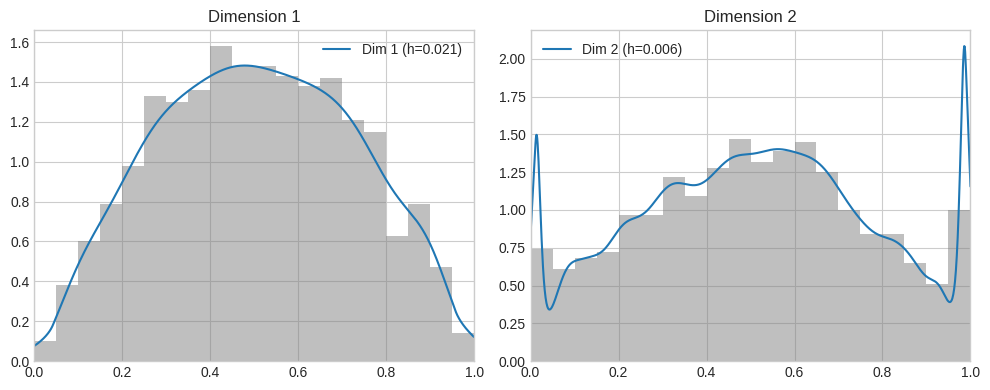

In [33]:
kde_2d.plot()

Or you can use the internal LSCV or LCV bandwidth selection.

In [34]:
kde_beta = BetaKDE(bandwidth='LCV', verbose=1).fit(X)

Bandwidth selected by MISE rule: h = 0.0382


## Probabilistic Modeling & Classification (Naive Bayes)
Since BetaKDE gives us a probabilistic model of the data, we can use it to build a Generative Classifier.

In this example, we classify data points into two classes (0 and 1) by fitting a separate BetaKDE to each class and choosing the one that assigns a higher likelihood to new points.

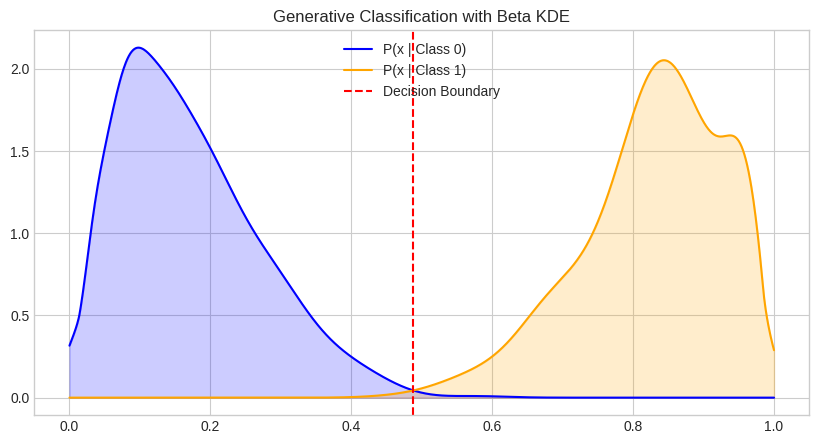

Decision Boundary found at x ≈ 0.487


In [35]:
from sklearn.metrics import accuracy_score

# 1. Generate Synthetic Data
# Class 0: Skewed towards 0 (e.g., Beta(2, 10))
# Class 1: Skewed towards 1 (e.g., Beta(10, 2))
np.random.seed(42)
n_per_class = 500

X0 = np.random.beta(2, 10, size=(n_per_class, 1))
X1 = np.random.beta(10, 2, size=(n_per_class, 1))

# Create training set
X_train = np.vstack([X0, X1])
y_train = np.array([0] * n_per_class + [1] * n_per_class)

# 2. Train models (One per class)
kde0 = BetaKDE(bandwidth='beta-reference').fit(X0)
kde1 = BetaKDE(bandwidth='beta-reference').fit(X1)

# 3. Predict on Grid
x_grid = np.linspace(0, 1, 1000).reshape(-1, 1)

# Calculate Log-Likelihoods for each class
log_prob_0 = kde0.score_samples(x_grid) + np.log(0.5) # Assuming equal priors
log_prob_1 = kde1.score_samples(x_grid) + np.log(0.5)

# Decision Boundary: Where prob_0 == prob_1
boundary_idx = np.argwhere(np.diff(np.sign(log_prob_0 - log_prob_1))).flatten()
decision_boundary = x_grid[boundary_idx]

# 4. Plot
plt.figure(figsize=(10, 5))

# Plot Densities
plt.plot(x_grid, np.exp(log_prob_0), label='P(x | Class 0)', color='blue')
plt.plot(x_grid, np.exp(log_prob_1), label='P(x | Class 1)', color='orange')

# Plot Decision Boundary
for b in decision_boundary:
    plt.axvline(b, color='red', linestyle='--', label='Decision Boundary')

plt.fill_between(x_grid.flatten(), 0, np.exp(log_prob_0), alpha=0.2, color='blue')
plt.fill_between(x_grid.flatten(), 0, np.exp(log_prob_1), alpha=0.2, color='orange')

plt.title("Generative Classification with Beta KDE")
plt.legend()
plt.show()

print(f"Decision Boundary found at x ≈ {decision_boundary[0][0]:.3f}")

## Custom Bounds (e.g., 0 to 100%)
Your data might not be in $[0, 1]$. It might be percentages $[0, 100]$ or a physical measurement like $[0, 10]$.

BetaKDE handles this automatically via the bounds parameter. It scales the data internally for fitting and scales it back for prediction.

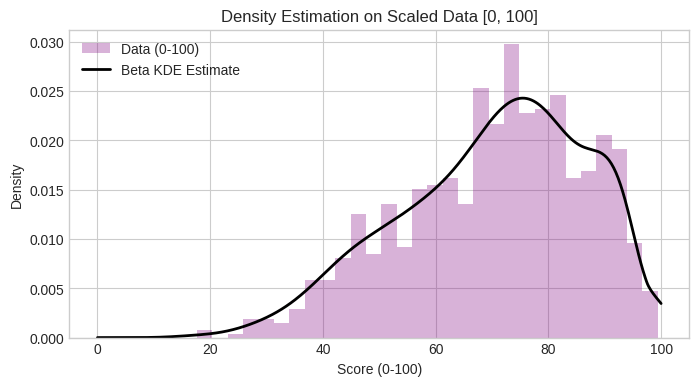

In [36]:
# 1. Generate Data in [0, 100]
np.random.seed(99)
# Beta distribution scaled up to 100
data_scaled = np.random.beta(5, 2, size=(1000, 1)) * 100 

# 2. Fit with custom bounds
kde_scaled = BetaKDE(bounds=(0, 100), bandwidth='beta-reference')
kde_scaled.fit(data_scaled)

# 3. Plot
# Note: The x-axis is now 0 to 100
x_grid_scaled = np.linspace(0, 100, 500).reshape(-1, 1)
pdf_scaled = kde_scaled.pdf(x_grid_scaled, normalized=True)

plt.figure(figsize=(8, 4))
plt.hist(data_scaled, bins=30, density=True, alpha=0.3, color='purple', label='Data (0-100)')
plt.plot(x_grid_scaled, pdf_scaled, 'k-', lw=2, label='Beta KDE Estimate')

plt.title("Density Estimation on Scaled Data [0, 100]")
plt.xlabel("Score (0-100)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Scikit-learn Integration
Because BetaKDE inherits from BaseEstimator, it is fully compatible with Scikit-learn's ecosystem. 

## Bandwidth selection using GridSearchCV
You can use GridSearchCV to optimize the bandwidth if the default rule-of-thumb isn't perfect for your specific dataset.

In [37]:
# 1. Define Parameter Grid
# We compare the automatic 'beta-reference' rule against fixed bandwidths
param_grid = {
    'bandwidth': ['beta-reference', 0.05, 0.1, 0.2]
}

# 2. Run Grid Search (using 3-fold cross-validation)
grid = GridSearchCV(BetaKDE(), param_grid, cv=3)
grid.fit(X) # Using the 1D data from Example 1

print("Best Bandwidth:", grid.best_params_['bandwidth'])
print("Best Score (Log-Likelihood):", grid.best_score_)

# 3. Check results
import pandas as pd
results = pd.DataFrame(grid.cv_results_)
results[['param_bandwidth', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score')

Best Bandwidth: beta-reference
Best Score (Log-Likelihood): 727.859088017229


,param_bandwidth,mean_test_score,rank_test_score
0,beta-reference,727.859088,1
1,0.05,727.004528,2
2,0.1,698.926831,3
3,0.2,570.336107,4


## Benchmarking with Cross-Validation
Because BetaKDE is a valid Scikit-learn estimator, you can use standard tools like cross_val_score to benchmark it against other models.

Here, we rigorously compare the log-likelihood of BetaKDE versus Gaussian KernelDensity on bounded data.

In [38]:
from sklearn.model_selection import cross_val_score

# 1. Generate Bounded Data
np.random.seed(100)
data = np.random.beta(2, 5, size=(1000, 1))

# 2. Define Models
# Model A: Beta KDE (Auto-bandwidth)
kde_beta = BetaKDE(bandwidth='beta-reference')

# Model B: Gaussian KDE (Silverman rule)
kde_gauss = KernelDensity(kernel='gaussian', bandwidth='silverman')

# 3. Run 5-Fold Cross-Validation
# Returns log-likelihoods for each fold
scores_beta = cross_val_score(kde_beta, data, cv=5)
scores_gauss = cross_val_score(kde_gauss, data, cv=5)

# 4. Results
print(f"Beta KDE Mean Score:     {np.mean(scores_beta):.4f} (Std: {np.std(scores_beta):.4f})")
print(f"Gaussian KDE Mean Score: {np.mean(scores_gauss):.4f} (Std: {np.std(scores_gauss):.4f})")

# Higher score (less negative) is better
if np.mean(scores_beta) > np.mean(scores_gauss):
    print("\n✅ Beta KDE fits the data better.")
else:
    print("\n❌ Gaussian KDE fits the data better.")

Beta KDE Mean Score:     98.8360 (Std: 13.7016)
Gaussian KDE Mean Score: 21.5522 (Std: 3.0195)

✅ Beta KDE fits the data better.
